In [2]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import numpy as np

In [6]:
cores_buscas = {
    "BFS": "#FF0055",      
    "DFS": "#00B3FF",      
    "UCS": "#FFCC00",      
    "Gulosa": "#9900FF",   
    "A*": "#00FF66",       
}

In [ ]:
df_maze = pd.read_csv('/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/mazes.csv')

arquivos = {
    'BFS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_bfs.csv',
    'DFS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_dfs.csv',
    'UCS': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_ucs.csv',
    'Gulosa': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_guloso.csv',
    'A*': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_a_star.csv',
}

dfs = []
for nome_algoritmo, caminho_arquivo in arquivos.items():
    try:
        df_temp = pd.read_csv(caminho_arquivo)
        df_temp['Algoritmo'] = nome_algoritmo
        
        df_temp['Execucao'] = df_temp.index + 1 
        
        
        # for i, row in df_astar.iterrows():
        #     listOnOff.append((row['custo_online'] / row['custo']))

        dfConcat = pd.concat([df_temp, df_maze['cicles'], df_maze['width'], df_maze['length'], df_maze['start'], df_maze['end']], axis=1)

        dfs.append(dfConcat)
    except FileNotFoundError:
        print(f"Atenção: O arquivo {caminho_arquivo} não foi encontrado.")

df_completo = pd.concat(dfs, ignore_index=True)

df_completo

Dados carregados com sucesso! Total de linhas: 500


,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,Algoritmo,Execucao,cicles,width,length,start,end
0,141a00ac-07df-42fd-a263-607b9174eab0,True,130,131,377,377,0.000803,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS,1,0.310348,61,41,"(1, 1)","(59, 39)"
1,9213bf65-9c52-448c-9f9a-825316d2aae7,True,106,107,1438,1438,0.002280,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3...",BFS,2,0.143216,83,13,"(1, 1)","(81, 11)"
2,5272f069-12b4-49a0-b886-0d49a7de15d5,True,32,33,58,60,0.000107,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",BFS,3,0.091586,49,81,"(1, 1)","(47, 79)"
3,f31e608f-894c-44ba-8b1b-cd541a803495,True,108,109,1895,1895,0.003446,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS,4,0.049497,49,27,"(1, 1)","(47, 25)"
4,c3757c3b-25ff-4740-be1c-026403ab046d,True,118,119,1989,1989,0.002973,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",BFS,5,0.013778,57,41,"(1, 1)","(55, 39)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,b6741511-5a3c-458e-b219-12423e1312ce,True,118,119,1013,78,0.002307,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",A*,96,0.488248,91,13,"(1, 1)","(89, 11)"
496,e8aee1de-66b9-480b-9594-dcf2d40e1074,True,70,71,291,38,0.000620,"[(1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3...",A*,97,0.255804,97,51,"(1, 1)","(95, 49)"
497,f0a566b3-fe0f-46b2-8acc-1924b0ced6dc,True,50,51,211,21,0.000611,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",A*,98,0.107361,61,83,"(1, 1)","(59, 81)"
498,b477d218-6cf4-49d7-a547-07a60a598ad3,True,140,141,821,81,0.001825,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4...",A*,99,0.069655,15,15,"(1, 1)","(13, 13)"


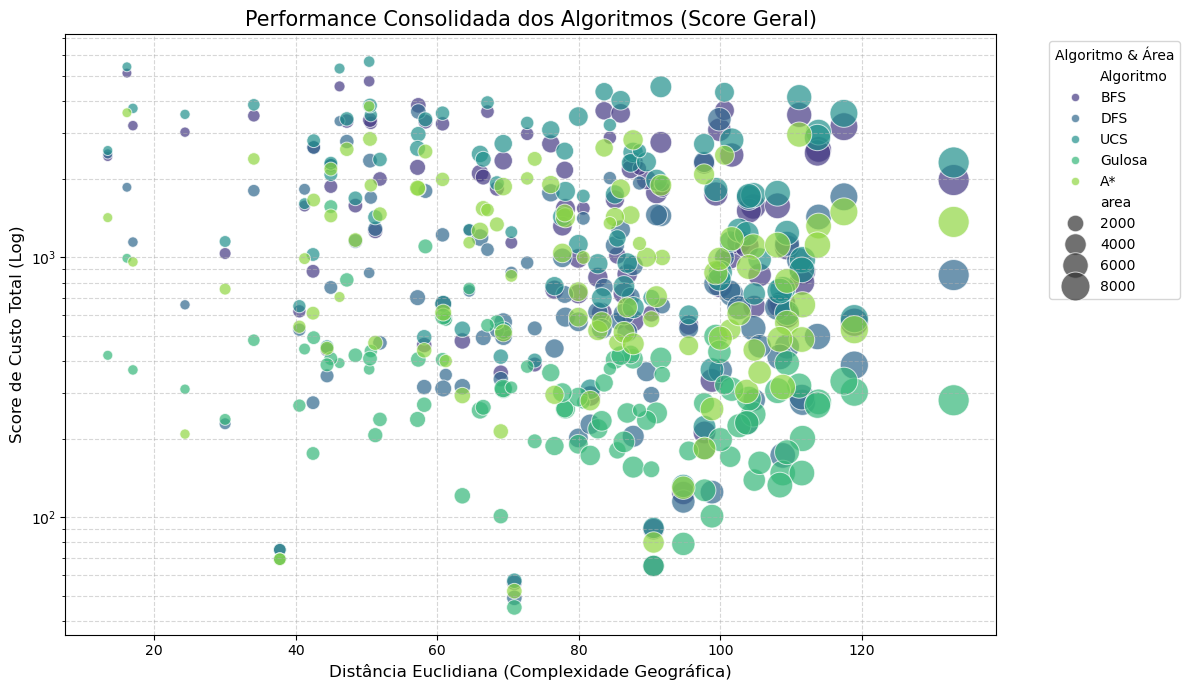

In [8]:
# 1. Configuração de Pesos (Ajuste conforme a prioridade do seu trabalho)
alpha, beta, gamma, delta, epsilon = 1.0, 1.0, 1.0, 1.0, 1.0

# 2. Limpeza e Pré-processamento
# Converte as coordenadas de string '(1, 1)' para tupla
def converter_string_para_tupla(coord_str):
    if isinstance(coord_str, str):
        parts = coord_str.replace('(', '').replace(')', '').split(',')
        return (int(parts[0].strip()), int(parts[1].strip()))
    return coord_str

df_full = df_completo.copy()
df_full['start_tupla'] = df_full['start'].apply(converter_string_para_tupla)
df_full['end_tupla'] = df_full['end'].apply(converter_string_para_tupla)

# Cálculo da Distância Euclidiana
df_full['distancia_euclidiana'] = df_full.apply(
    lambda row: np.sqrt((row['end_tupla'][0] - row['start_tupla'][0])**2 + 
                        (row['end_tupla'][1] - row['start_tupla'][1])**2), axis=1
)

# Cálculo da Área
df_full['area'] = df_full['width'] * df_full['length']

# 3. Cálculo do Score com todas as métricas disponíveis
# Garantimos que colunas faltantes (se houver) sejam tratadas como 0
df_full['celulas_revisitadas'] = df_full.get('celulas_revisitadas', 0)
df_full['replanejamentos'] = df_full.get('replanejamentos', 0)

# Aplicando a fórmula: Custo + (custo_expandindo + tempo + mov_inv + revisita)
# Invertemos os sinais de penalidade para que o valor final seja positivo
df_full['score'] = (
    (alpha * df_full['custo']) +
    (beta * df_full['expandidos']) + 
    (gamma * df_full['tempo_segundos']) + 
    (delta * df_full['replanejamentos']) + 
    (epsilon * df_full['celulas_revisitadas'])
)

# 4. Visualização
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_full,
    x='distancia_euclidiana', 
    y='score',
    hue='Algoritmo',
    size='area', 
    sizes=(50, 500),
    palette='viridis',
    alpha=0.7
)

# Opcional: Escala logarítmica no Y se o score variar ordens de grandeza
plt.yscale('log') 

plt.title('Performance Consolidada dos Algoritmos (Score Geral)', fontsize=15)
plt.xlabel('Distância Euclidiana (Complexidade Geográfica)', fontsize=12)
plt.ylabel('Score de Custo Total (Log)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Algoritmo & Área')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

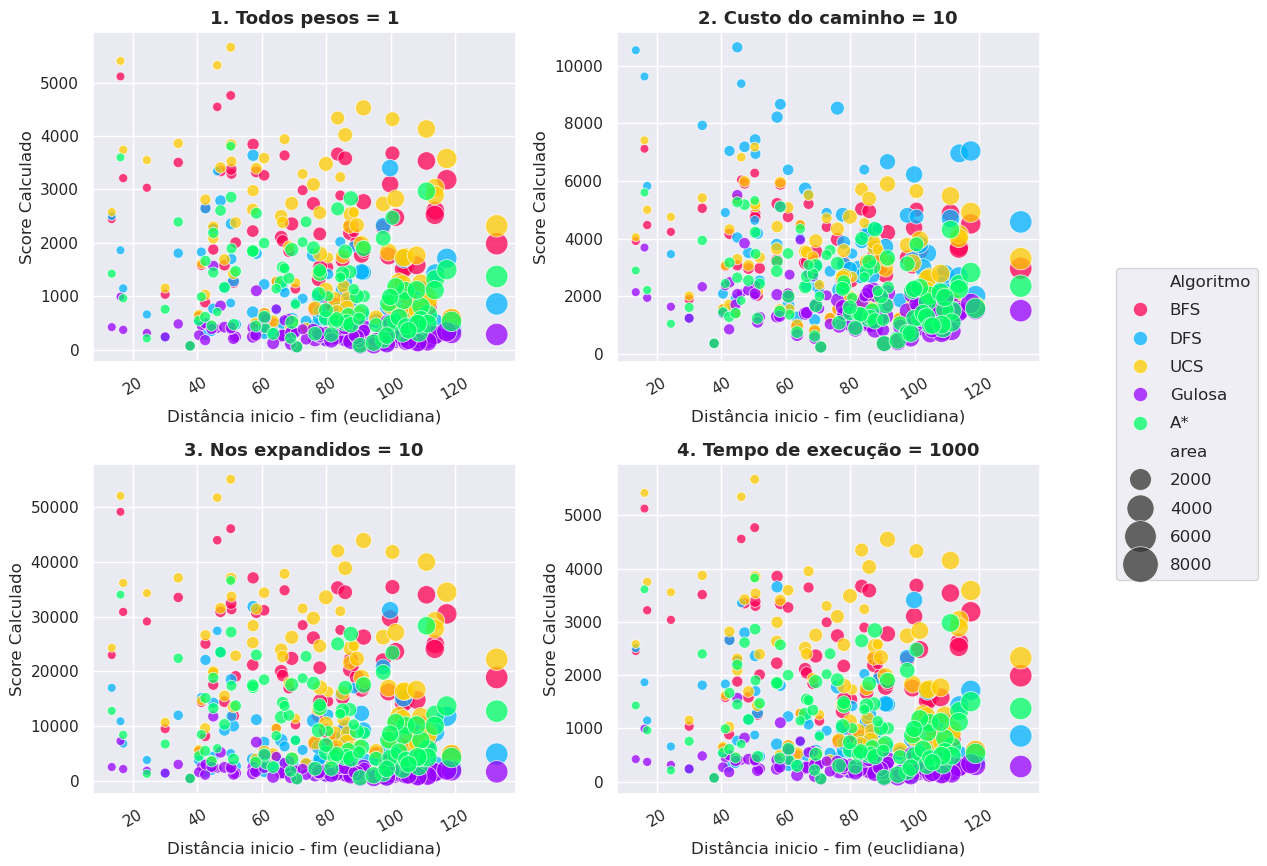

In [17]:
sns.set_theme(style="darkgrid")

cenarios = {
    "1. Todos pesos = 1": [1, 1, 1],
    "2. Custo do caminho = 10":   [10, 1, 1],
    "3. Nos expandidos = 10": [1, 10, 1],
    "4. Tempo de execução = 1000": [1, 1, 1000],
    # "5. Foco em Replanejamentos": [1, 1, 1, 10, 1],
    # "6. Foco em Revisitas":       [1, 1, 1, 1, 10],
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

ordem_buscas = ["BFS", "DFS", "UCS", "Gulosa", "A*"]

for ax, (titulo, pesos) in zip(axes, cenarios.items()):
    alpha, beta, gamma = pesos
    
    df_temp = df_full.copy()
    df_temp['score_cenario'] = (
        (alpha * df_temp['custo']) + 
        (beta * df_temp['expandidos']) + 
        (gamma * df_temp['tempo_segundos']) 
        # (delta * df_temp.get('replanejamentos', 0)) + 
        # (epsilon * df_temp.get('celulas_revisitadas', 0))
    )
    
    sns.scatterplot(
        data=df_temp,
        x="distancia_euclidiana",
        y="score_cenario",
        hue="Algoritmo",
        palette=cores_buscas,
        hue_order=ordem_buscas,
        size="area",
        sizes=(40, 260),
        alpha=0.75,
        ax=ax,
    )
    
    ax.set_title(f"{titulo}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Distância inicio - fim (euclidiana)")
    ax.set_ylabel("Score Calculado")
    # ax.set_yscale("log")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
legenda = fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    markerscale=1.7,
    fontsize=12,
    title_fontsize=13,
    labelspacing=0.8,
)

for handle in legenda.legend_handles:
    if hasattr(handle, "get_sizes") and hasattr(handle, "set_sizes"):
        handle.set_sizes(handle.get_sizes() * 1.8)

plt.tight_layout(rect=[0, 0, 0.82, 0.98])
plt.savefig("figs/comparativo_pesos_formula.png", bbox_inches="tight", dpi=300)
plt.show()

In [27]:
df_maze = pd.read_csv('/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/mazes.csv')

arquivos_online = {
    'A*': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_a_star.csv',
    'Online A*': '/home/pedroalves/faculdade/8-periodo/ia/maze-solving-ai-agent/datasets/resultado_online_a_star.csv'
}

dfs = []
for nome_algoritmo, caminho_arquivo in arquivos_online.items():
    try:
        df_temp = pd.read_csv(caminho_arquivo)
        df_temp['Algoritmo'] = nome_algoritmo
        df_temp['Execucao'] = df_temp.index + 1 
        
        dfConcat = pd.concat([
            df_temp, 
            df_maze[['cicles', 'width', 'length', 'start', 'end']]
        ], axis=1)

        dfs.append(dfConcat)
    except FileNotFoundError:
        print(f"Atenção: O arquivo {caminho_arquivo} não foi encontrado.")

df_full = pd.concat(dfs, ignore_index=True)

def converter_string_para_tupla(coord_str):
    if isinstance(coord_str, str):
        parts = coord_str.replace('(', '').replace(')', '').split(',')
        return (int(parts[0].strip()), int(parts[1].strip()))
    return coord_str

df_full['start_tupla'] = df_full['start'].apply(converter_string_para_tupla)
df_full['end_tupla'] = df_full['end'].apply(converter_string_para_tupla)

df_full['distancia_euclidiana'] = df_full.apply(
    lambda row: np.sqrt((row['end_tupla'][0] - row['start_tupla'][0])**2 + 
                        (row['end_tupla'][1] - row['start_tupla'][1])**2), axis=1
)
df_full['area'] = df_full['width'] * df_full['length']

df_full.tail()

,maze_id,sucesso,custo,passos,expandidos,fronteira,tempo_segundos,caminho,Algoritmo,Execucao,...,length,start,end,celulas_reveladas,celulas_revisitadas,replanejamentos,start_tupla,end_tupla,distancia_euclidiana,area
195,95062f12-59b6-46dd-8dcd-0a3009d4b14f,True,242,242,308359,345054,1.201455,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",Online A*,96,...,13,"(1, 1)","(89, 11)",586.0,19.0,242.0,"(1, 1)","(89, 11)",88.566359,1183
196,b6741511-5a3c-458e-b219-12423e1312ce,True,158,158,165978,184294,0.661397,"[(1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1...",Online A*,97,...,51,"(1, 1)","(95, 49)",411.0,5.0,158.0,"(1, 1)","(95, 49)",105.546198,4947
197,e0a1fad4-629a-46ce-830c-9debf8080b2a,True,240,240,424251,460865,1.429186,"[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6...",Online A*,98,...,83,"(1, 1)","(59, 81)",627.0,2.0,240.0,"(1, 1)","(59, 81)",98.812955,5063
198,b477d218-6cf4-49d7-a547-07a60a598ad3,True,182,182,233877,258462,0.671463,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4...",Online A*,99,...,15,"(1, 1)","(13, 13)",487.0,0.0,182.0,"(1, 1)","(13, 13)",16.970563,225
199,b5a8bbf8-864f-4441-8057-73dfacb3c515,True,178,178,301012,325915,0.871074,"[(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4...",Online A*,100,...,89,"(1, 1)","(81, 87)",455.0,6.0,178.0,"(1, 1)","(81, 87)",117.456375,7387


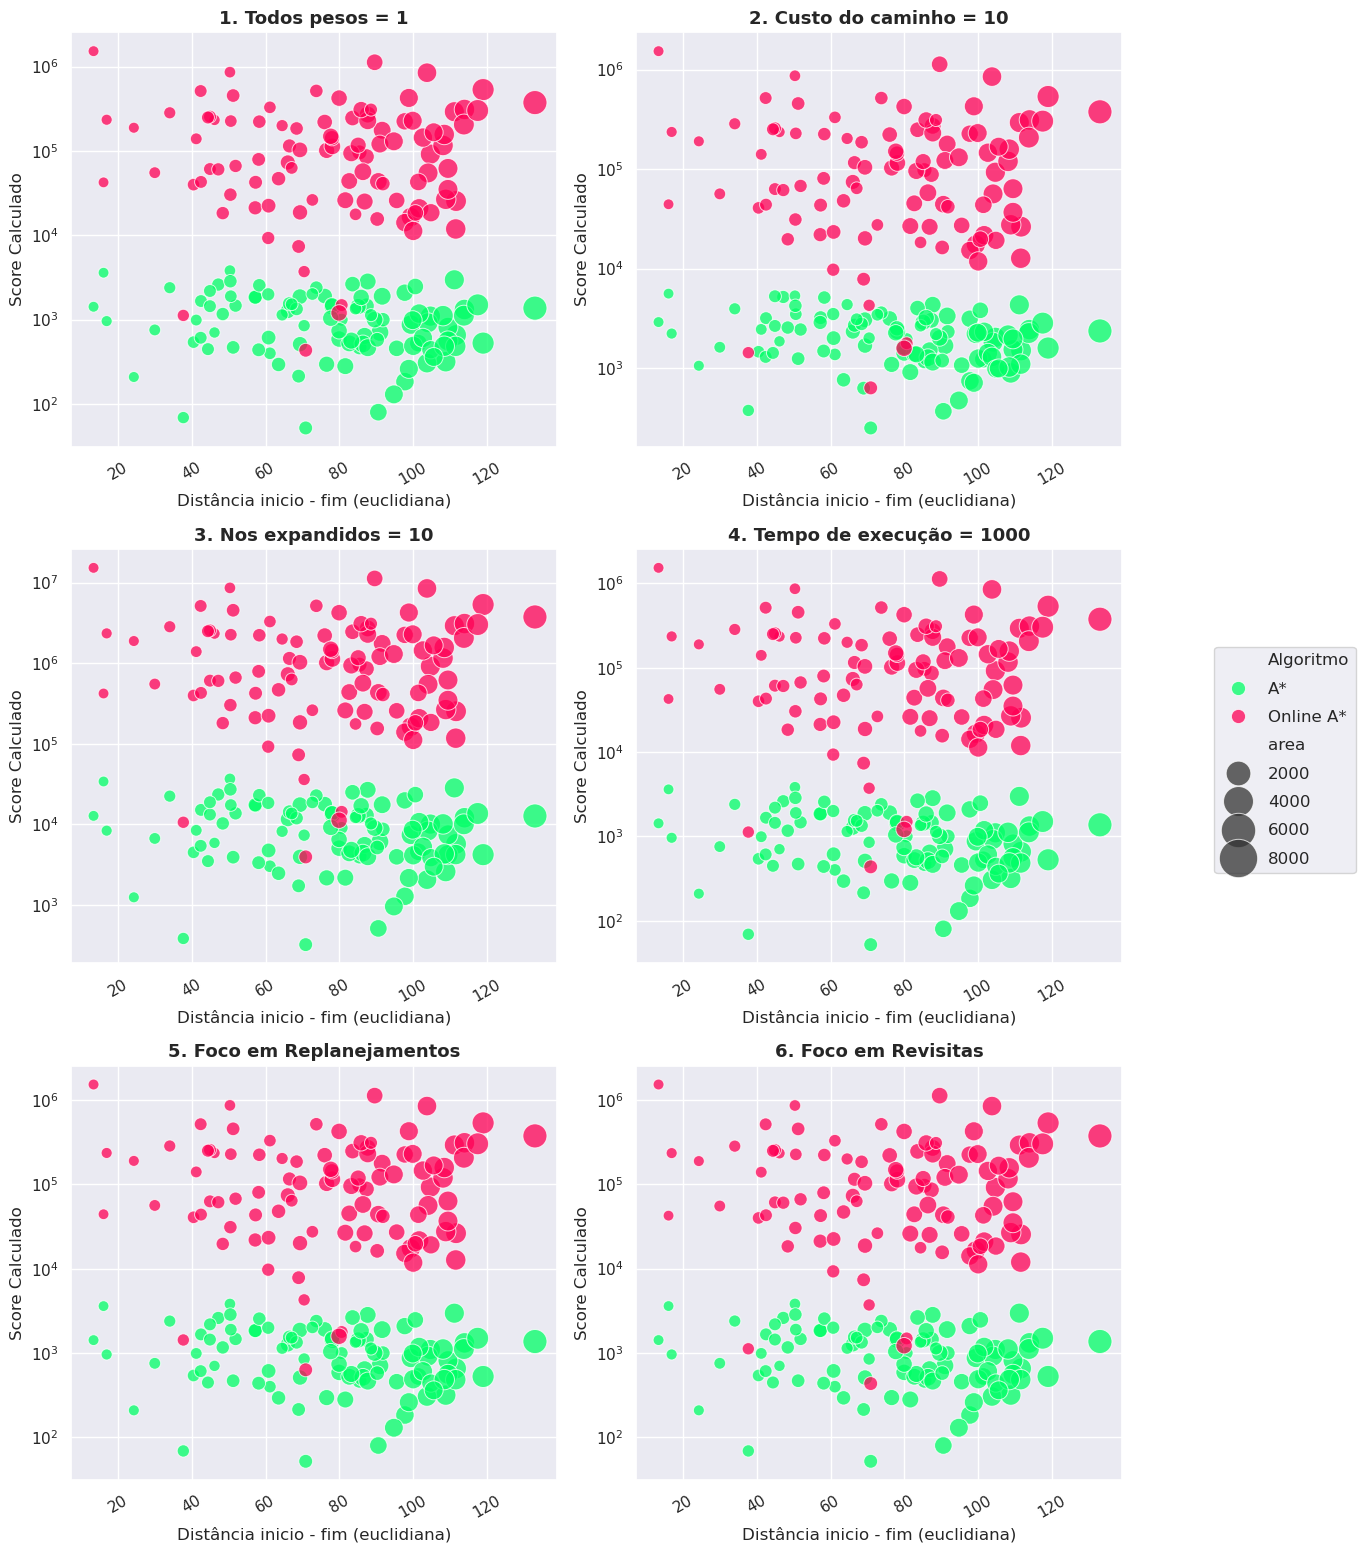

In [ ]:
sns.set_theme(style="darkgrid")

cenarios = {
    "1. Todos pesos = 1":            [1, 1, 1, 1, 1],
    "2. Custo do caminho = 10":      [10, 1, 1, 1, 1],
    "3. Nos expandidos = 10":        [1, 10, 1, 1, 1],
    "4. Tempo de execução = 1000":   [1, 1, 1000, 1, 1],
    "5. Replanejamentos = 10":    [1, 1, 1, 10, 1],
    "6. Revisitas = 10":          [1, 1, 1, 1, 10],
}

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

ordem_buscas = ["A*", "Online A*"]
cores_buscas = {
    "A*": "#00FF66",
    "Online A*": "#FF0055"
}

for ax, (titulo, pesos) in zip(axes, cenarios.items()):
    alpha, beta, gamma, delta, epsilon = pesos
    
    df_temp = df_full.copy()
    
    replanejamentos = df_temp.get('replanejamentos', pd.Series(0, index=df_temp.index)).fillna(0)
    revisitas = df_temp.get('celulas_revisitadas', pd.Series(0, index=df_temp.index)).fillna(0)
    
    df_temp['score_cenario'] = (
        (alpha * df_temp['custo']) + 
        (beta * df_temp['expandidos']) + 
        (gamma * df_temp['tempo_segundos']) + 
        (delta * replanejamentos) + 
        (epsilon * revisitas)
    )
    
    sns.scatterplot(
        data=df_temp,
        x="distancia_euclidiana",
        y="score_cenario",
        hue="Algoritmo",
        palette=cores_buscas,
        hue_order=ordem_buscas,
        size="area",
        sizes=(60, 300),
        alpha=0.75,
        ax=ax,
    )
    
    ax.set_title(f"{titulo}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Distância inicio - fim (euclidiana)")
    ax.set_ylabel("Score Calculado")
    
    ax.set_yscale("log") 
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()

# Configuração da Legenda Global Fora dos Gráficos
handles, labels = axes[0].get_legend_handles_labels()
legenda = fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    markerscale=1.7,
    fontsize=12,
    title_fontsize=13,
    labelspacing=0.8,
)

for handle in legenda.legend_handles:
    if hasattr(handle, "get_sizes") and hasattr(handle, "set_sizes"):
        handle.set_sizes(handle.get_sizes() * 1.8)

plt.tight_layout(rect=[0, 0, 0.82, 0.98])
plt.savefig("figs/comparativo_online_offline_pesos.png", bbox_inches="tight", dpi=300)
plt.show()

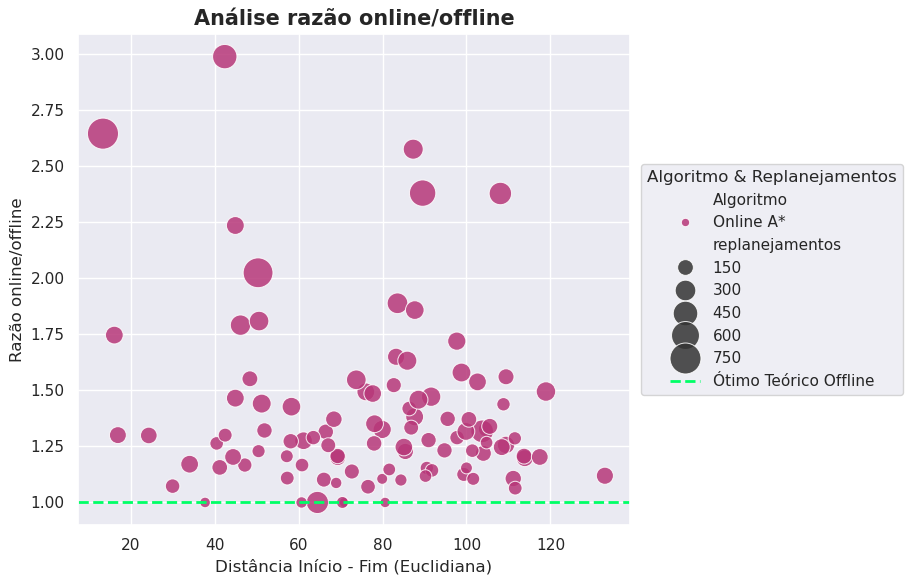

In [33]:
cores = {
    "0.1": "#FF0055",      
    "0.2": "#00B3FF",      
    "0.3": "#FFCC00",      
    "0.4": "#9900FF",   
    "0.5": "#00FF66",       
}

df_astar = df_full[df_full['Algoritmo'] == 'A*'].copy()
df_online = df_full[df_full['Algoritmo'] == 'Online A*'].copy()

df_comp = pd.merge(
    df_online,
    df_astar[['maze_id', 'custo', 'expandidos']],
    on='maze_id',
    suffixes=('_online', '_offline')
)

df_comp['razao_competitividade'] = df_comp['custo_online'] / df_comp['custo_offline']

sns.set_theme(style="darkgrid")
plt.figure(figsize=(11, 6))

scatter = sns.scatterplot(
    data=df_comp,
    x='distancia_euclidiana',
    y='razao_competitividade',
    size='replanejamentos',
    hue='Algoritmo',
    palette='magma',
    sizes=(50, 500),
    alpha=0.85
)

plt.axhline(1.0, color='#00FF66', linestyle='--', linewidth=2, label='Ótimo Teórico Offline')

plt.title('Análise razão online/offline', fontsize=15, fontweight='bold')
plt.xlabel('Distância Início - Fim (Euclidiana)', fontsize=12)
plt.ylabel('Razão online/offline', fontsize=12)

plt.legend(
    bbox_to_anchor=(1.02, 0.5), 
    loc="center left", 
    title='Algoritmo & Replanejamentos',
    borderaxespad=0
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig("figs/razao_online.png", bbox_inches="tight", dpi=300)
plt.show()